
# Explicabilidad SHAP - BNBUSDT (residual_hybrid *staged*, `core_only`)

Notebook de explicabilidad sobre el modelo congelado de BNBUSDT
(`residual_hybrid`, etiquetado `trend_scanning`, inyección `staged`,
bloque `core_only`). Estudio:
`greedy_bnbusdt_trend_scanning_residual_hybrid_staged_core_only_20260505T012242Z_frozen_20260517T134241Z`
(fold_094). El stage1 LSTM se reconstruye desde `lstm_stage1_state.pt`
(refit oficial) y el corrector XGBoost se carga desde `model_state.joblib`.


In [14]:

from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (
    REPO_ROOT / "src" / "validation" / "model_explainability.py"
).exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src" / "validation" / "model_explainability.py").exists():
    raise SystemExit("No se localiza la raíz del repo del TFG.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PROMOTION_MANIFEST = REPO_ROOT / "reports/validation/promotion/20260520T153716Z/promotion_manifest.json"
EXPL_REPORT_ROOT = REPO_ROOT / "reports" / "validation" / "explainability"
EXPL_REPORT_ROOT.mkdir(parents=True, exist_ok=True)


In [15]:

SYMBOL = "BNBUSDT"

from src.validation.model_explainability import (
    align_xgb_proba,
    build_corrector_input,
    build_sequence_windows,
    compute_lstm_signal_features,
    explain_corrector_kernel_shap,
    load_fold_datasets,
    load_promotion_champions,
    load_residual_hybrid_pair,
    load_simple_lstm_classifier,
    predict_lstm_softmax,
)

handles = load_promotion_champions(PROMOTION_MANIFEST, repo_root=REPO_ROOT)
handle = handles[SYMBOL]

SYMBOL_REPORT_DIR = EXPL_REPORT_ROOT / SYMBOL.lower()
SYMBOL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Símbolo          :", handle.symbol)
print("Carril           :", handle.lane)
print("Familia          :", handle.family)
print("Familia_motor    :", handle.engine_family)
print("Etiquetado       :", handle.labeling_method)
print("Inyección        :", handle.injection_strategy)
print("Bloques_activos  :", handle.active_blocks_id)
print("Id_estudio       :", handle.study_id)
print("Dir_ultimo_fold  :", handle.last_fold_dir.relative_to(REPO_ROOT).as_posix())
print("Dir_modelos_fold:", handle.fold_models_dir.relative_to(REPO_ROOT).as_posix())
print("Canales          :", len(handle.feature_channel_order))
print("Barras_lookback  :", handle.lookback_bars)


Símbolo          : BNBUSDT
Carril           : primary
Familia          : residual_hybrid
Familia_motor    : residual_hybrid
Etiquetado       : trend_scanning
Inyección        : staged
Bloques_activos  : core_only
Id_estudio       : greedy_bnbusdt_trend_scanning_residual_hybrid_staged_core_only_20260505T012242Z_frozen_20260517T134241Z
Dir_ultimo_fold  : reports/validation/experiments/greedy_bnbusdt_trend_scanning_residual_hybrid_staged_core_only_20260505T012242Z_frozen_20260517T134241Z/folds/fold_094
Dir_modelos_fold: reports/validation/experiments/greedy_bnbusdt_trend_scanning_residual_hybrid_staged_core_only_20260505T012242Z_frozen_20260517T134241Z/folds/fold_094/models/residual_hybrid
Canales          : 17
Barras_lookback  : 42


## 1. Datos del *fold* congelado y tensorización causal


In [16]:

datasets = load_fold_datasets(handle)
train_df, test_df = datasets["train"], datasets["test"]
print("Filas entrenamiento:", train_df.shape, "| filas test:", test_df.shape)

windowed = build_sequence_windows(
    train_df,
    test_df,
    feature_channel_order=handle.feature_channel_order,
    lookback_bars=handle.lookback_bars,
)
X_train, X_test = windowed["X_train"], windowed["X_test"]
y_train, y_test = windowed["y_train"], windowed["y_test"]
aligned_train = windowed["aligned_train"]
aligned_test = windowed["aligned_test"]
feature_channels = list(windowed["feature_channel_order"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train cuenta:", dict(zip(*np.unique(y_train, return_counts=True))))
print("y_test  cuenta:", dict(zip(*np.unique(y_test, return_counts=True))))


Filas entrenamiento: (1080, 49) | filas test: (180, 49)
X_train: (1039, 42, 17) | X_test: (180, 42, 17)
y_train cuenta: {0: 447, 1: 1, 2: 591}
y_test  cuenta: {0: 121, 2: 59}



## 2. Stage1 LSTM + stage2 XGBoost: matriz completa de entrada al corrector

El stage1 (LSTM) se carga desde el `lstm_stage1_state.pt` del *refit* oficial,
genera las probabilidades por clase y deriva las seis señales
`lstm_proba_side_*`, `lstm_margin`, `lstm_confidence`, `lstm_entropy`.
El corrector XGBoost (stage2) recibe la concatenación de
`corrector_base_feature_columns` -> seis señales LSTM en el orden exacto
declarado por `stage2_feature_columns` en el manifiesto del *fold*. Para BNBUSDT
la lista base está vacía (solo seis señales); para ETHUSDT y SOLUSDT incluye
además las columnas del bloque activo (`sentiment` o `derivatives_futures`).


In [17]:

lstm_model, corrector, residual_manifest = load_residual_hybrid_pair(handle)

stage1_proba_train = predict_lstm_softmax(lstm_model, X_train)
stage1_proba_test = predict_lstm_softmax(lstm_model, X_test)
signal_train = compute_lstm_signal_features(stage1_proba_train).reset_index(drop=True)
signal_test = compute_lstm_signal_features(stage1_proba_test).reset_index(drop=True)

corrector_input_train = build_corrector_input(
    aligned_train.reset_index(drop=True), signal_train, residual_manifest,
)
corrector_input_test = build_corrector_input(
    aligned_test.reset_index(drop=True), signal_test, residual_manifest,
)
corrector_feature_names = list(corrector_input_test.columns)

print("Columnas_stage2         :", residual_manifest["stage2_feature_columns"])
print("Columnas_base_corrector :", residual_manifest["corrector_base_feature_columns"])
print("Forma_entrada_train     :", corrector_input_train.shape)
print("Forma_entrada_test      :", corrector_input_test.shape)
corrector_input_test.describe().T


Columnas_stage2         : ['lstm_proba_side_neg', 'lstm_proba_side_neutral', 'lstm_proba_side_pos', 'lstm_margin', 'lstm_confidence', 'lstm_entropy']
Columnas_base_corrector : []
Forma_entrada_train     : (1039, 6)
Forma_entrada_test      : (180, 6)


,count,mean,std,min,25%,50%,75%,max
lstm_proba_side_neg,180.0,0.381557,0.018908,0.342337,0.368030,0.381410,0.392539,0.431072
lstm_proba_side_neutral,180.0,0.055689,0.004317,0.048429,0.052862,0.055031,0.057667,0.068457
lstm_proba_side_pos,180.0,0.562754,0.020841,0.511159,0.549222,0.562535,0.579209,0.604224
lstm_margin,180.0,0.181197,0.039560,0.080585,0.158140,0.182410,0.211467,0.258935
lstm_confidence,180.0,0.562754,0.020841,0.511159,0.549222,0.562535,0.579209,0.604224
lstm_entropy,180.0,0.850980,0.014206,0.819781,0.839927,0.850160,0.860774,0.885607


## 3. SHAP del stage1 LSTM (canales técnicos)

Aplicamos `shap.GradientExplainer` sobre el LSTM congelado del stage1 con un
*background* de 50 ventanas de entrenamiento y explicamos las primeras ~120
ventanas de evaluación. Esto nos da la atribución por **canal técnico** y
por **desplazamiento temporal**, complementaria al SHAP del corrector
(sección 4) que opera sobre las seis señales `lstm_*` (más, en su caso, las
columnas del bloque contextual activo).


In [18]:
import shap
import torch

SEED_STAGE1 = 17
rng_stage1 = np.random.default_rng(SEED_STAGE1)
stage1_background_size = min(50, X_train.shape[0])
stage1_explain_size = min(120, X_test.shape[0])

bg_idx_s1 = rng_stage1.choice(X_train.shape[0], size=stage1_background_size, replace=False)
ex_idx_s1 = np.arange(stage1_explain_size)

background_tensor_s1 = torch.from_numpy(X_train[bg_idx_s1]).float()
explain_tensor_s1 = torch.from_numpy(X_test[ex_idx_s1]).float()

lstm_model.eval()
explainer_s1 = shap.GradientExplainer(lstm_model, background_tensor_s1)
shap_values_s1 = explainer_s1.shap_values(explain_tensor_s1)
if isinstance(shap_values_s1, np.ndarray) and shap_values_s1.ndim == 4:
    shap_values_s1 = [shap_values_s1[..., k] for k in range(shap_values_s1.shape[-1])]

class_labels_s1 = [-1, 0, 1]
stage1_shap_by_class = {label: np.asarray(shap_values_s1[idx]) for idx, label in enumerate(class_labels_s1)}
print("Stage1 - n clases:", len(stage1_shap_by_class))
print("Stage1 - shape por clase:", {k: v.shape for k, v in stage1_shap_by_class.items()})


Stage1 - n clases: 3
Stage1 - shape por clase: {-1: (120, 42, 17), 0: (120, 42, 17), 1: (120, 42, 17)}


### 3.1 Importancia agregada por canal


In [19]:
stage1_feature_importance = {
    label: np.mean(np.abs(sv), axis=(0, 1)) for label, sv in stage1_shap_by_class.items()
}
stage1_importance_df = pd.DataFrame(stage1_feature_importance, index=feature_channels)
stage1_importance_df.columns = [f"clase_{c:+d}" for c in stage1_importance_df.columns]
stage1_importance_df["total"] = stage1_importance_df.abs().sum(axis=1)
stage1_importance_df = stage1_importance_df.sort_values("total", ascending=False)
stage1_importance_df.head(20)


,clase_-1,clase_+0,clase_+1,total
macd_line,0.000533,0.001325,0.002395,0.004253
vol_sma_ratio_20,0.000825,0.001425,0.000693,0.002943
macd_signal,0.001042,0.000587,0.000872,0.002501
obv,0.000704,0.000848,0.000725,0.002278
atr_14,0.000523,0.000888,0.000834,0.002245
pvt,0.000254,0.000682,0.001187,0.002124
roc_12,0.000889,0.000855,0.000313,0.002057
macd_hist,0.000849,0.000824,0.000332,0.002006
slope_sma_20,0.000429,0.001114,0.000380,0.001922
stoch_k_14,0.000432,0.000398,0.000951,0.001781


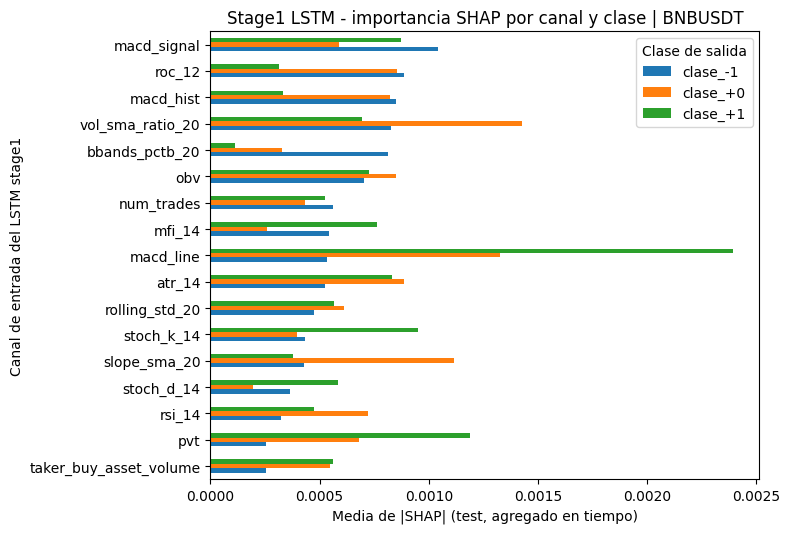

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, max(4.0, 0.32 * len(feature_channels))))
plot_df_s1 = stage1_importance_df.drop(columns="total").sort_values(by=stage1_importance_df.columns[0])
plot_df_s1.plot(kind="barh", ax=ax)
ax.set_xlabel("Media de |SHAP| (test, agregado en tiempo)")
ax.set_ylabel("Canal de entrada del LSTM stage1")
ax.set_title(f"Stage1 LSTM - importancia SHAP por canal y clase | {SYMBOL}")
ax.legend(title="Clase de salida")
plt.tight_layout()
fig.savefig(SYMBOL_REPORT_DIR / "shap_stage1_feature_importance.png", dpi=140)
plt.show()


### 3.2 Atribución temporal del stage1 (donde mira el LSTM dentro de la ventana)


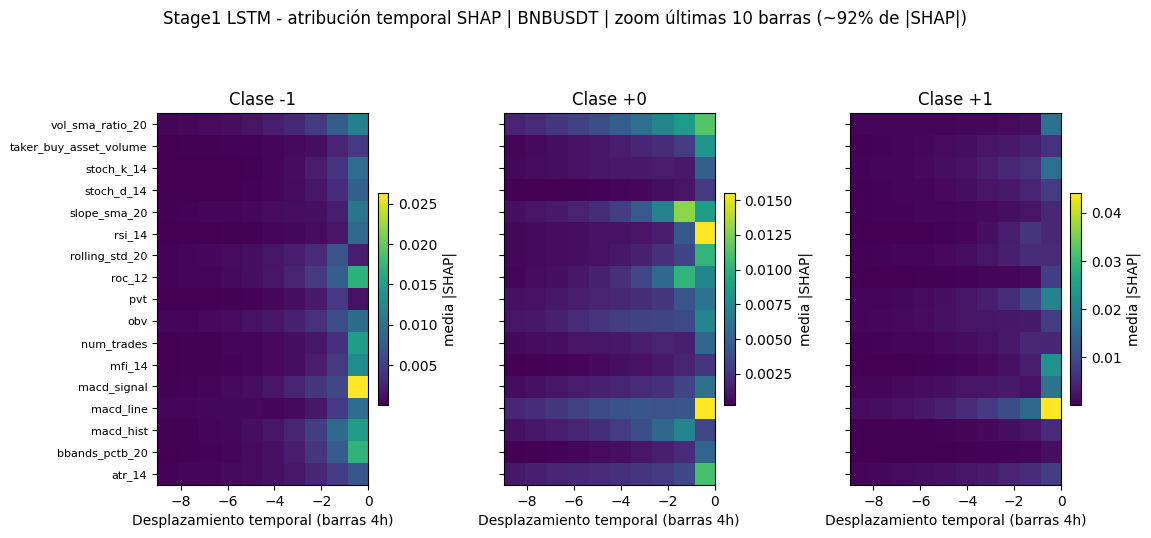

In [21]:
stage1_time_attr = {label: np.mean(np.abs(sv), axis=0) for label, sv in stage1_shap_by_class.items()}

lookback_s1 = int(handle.lookback_bars)
lag_labels_s1 = np.arange(-lookback_s1 + 1, 1)

stacked_s1 = np.stack(list(stage1_time_attr.values()), axis=0)
time_profile_s1 = np.mean(stacked_s1, axis=(0, 2))
total_mass_s1 = float(time_profile_s1.sum())
if total_mass_s1 > 0.0:
    cum_recent_s1 = np.cumsum(time_profile_s1[::-1])
    recent_bars_s1 = int(np.searchsorted(cum_recent_s1 / total_mass_s1, 0.90)) + 1
else:
    recent_bars_s1 = lookback_s1
recent_bars_s1 = int(np.clip(recent_bars_s1, min(10, lookback_s1), lookback_s1))
start_idx_s1 = lookback_s1 - recent_bars_s1
mass_pct_s1 = 100.0 * float(time_profile_s1[start_idx_s1:].sum() / max(total_mass_s1, 1e-12))
x_min_s1, x_max_s1 = int(lag_labels_s1[start_idx_s1]), 0

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, max(4.0, 0.32 * len(feature_channels))),
    sharey=True,
)
for ax, (label, mat) in zip(axes, stage1_time_attr.items()):
    mat_zoom = mat[start_idx_s1:, :]
    im = ax.imshow(
        mat_zoom.T,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=[x_min_s1, x_max_s1, -0.5, len(feature_channels) - 0.5],
    )
    ax.set_title(f"Clase {label:+d}")
    ax.set_xlabel("Desplazamiento temporal (barras 4h)")
    ax.set_yticks(range(len(feature_channels)))
    ax.set_yticklabels(feature_channels, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="media |SHAP|")
fig.suptitle(
    f"Stage1 LSTM - atribución temporal SHAP | {SYMBOL} | "
    f"zoom últimas {recent_bars_s1} barras (~{mass_pct_s1:.0f}% de |SHAP|)"
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.subplots_adjust(left=0.16, wspace=0.5)
fig.savefig(SYMBOL_REPORT_DIR / "shap_stage1_time_heatmap.png", dpi=140)
plt.show()



## 4. SHAP del stage2 corrector


In [22]:

import matplotlib.pyplot as plt

corrector_raw_proba_test = corrector.predict_proba(
    corrector_input_test.to_numpy(dtype=np.float32)
)
corrector_proba_test = align_xgb_proba(corrector, corrector_raw_proba_test)
corrector_pred_test = np.array([-1, 0, 1])[np.argmax(corrector_proba_test, axis=1)]
corrector_conf_test = corrector_proba_test.max(axis=1)
print("Corrector classes_:", getattr(corrector, "classes_", None))
print("Predicciones del corrector en test:", dict(zip(*np.unique(corrector_pred_test, return_counts=True))))

BG_SIZE = min(50, len(corrector_input_train))
N_EXPLAIN = min(120, len(corrector_input_test))
NSAMPLES = 200

explain_set = corrector_input_test.iloc[:N_EXPLAIN].reset_index(drop=True)
explanation = explain_corrector_kernel_shap(
    corrector,
    background=corrector_input_train,
    explain=explain_set,
    nsamples=NSAMPLES,
    random_state=17,
)
shap_by_class = explanation["shap_by_class"]
print("Clases SHAP:", list(shap_by_class.keys()))
print("Shape por clase:", {k: v.shape for k, v in shap_by_class.items()})


Corrector classes_: [0 1 2]
Predicciones del corrector en test: {1: 180}
Clases SHAP: [-1, 0, 1]
Shape por clase: {-1: (120, 6), 0: (120, 6), 1: (120, 6)}


### 4.1 Importancia agregada por señal (corrector)


In [23]:

feature_importance = {
    label: np.mean(np.abs(sv), axis=0) for label, sv in shap_by_class.items()
}
importance_df = pd.DataFrame(feature_importance, index=corrector_feature_names)
importance_df.columns = [f"clase_{c:+d}" for c in importance_df.columns]
importance_df["total"] = importance_df.abs().sum(axis=1)
importance_df = importance_df.sort_values("total", ascending=False)
importance_df


,clase_-1,clase_+0,clase_+1,total
lstm_margin,0.024919,0.000007,0.024912,0.049839
lstm_proba_side_neg,0.008109,0.000007,0.008116,0.016233
lstm_proba_side_neutral,0.000000,0.000000,0.000000,0.000000
lstm_proba_side_pos,0.000000,0.000000,0.000000,0.000000
lstm_confidence,0.000000,0.000000,0.000000,0.000000
lstm_entropy,0.000000,0.000000,0.000000,0.000000


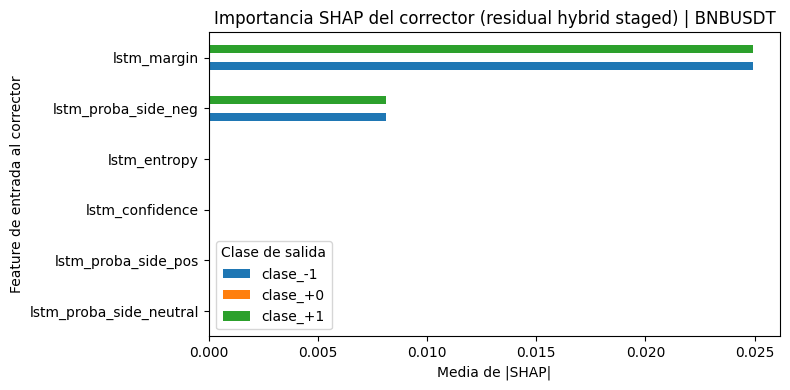

In [24]:

fig, ax = plt.subplots(figsize=(8, max(4.0, 0.32 * len(corrector_feature_names))))
plot_df = importance_df.drop(columns="total").sort_values(by=importance_df.columns[0])
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel("Media de |SHAP|")
ax.set_ylabel("Feature de entrada al corrector")
ax.set_title(f"Importancia SHAP del corrector (residual hybrid staged) | {SYMBOL}")
ax.legend(title="Clase de salida")
plt.tight_layout()
fig.savefig(SYMBOL_REPORT_DIR / "shap_feature_importance.png", dpi=140)
plt.show()


### 4.2 Beeswarm SHAP por clase (corrector)


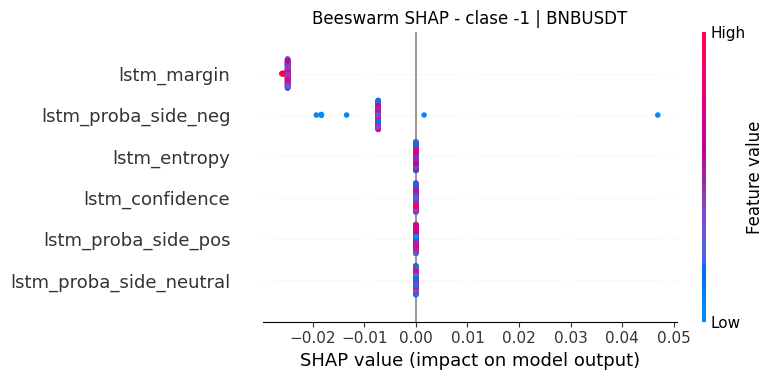

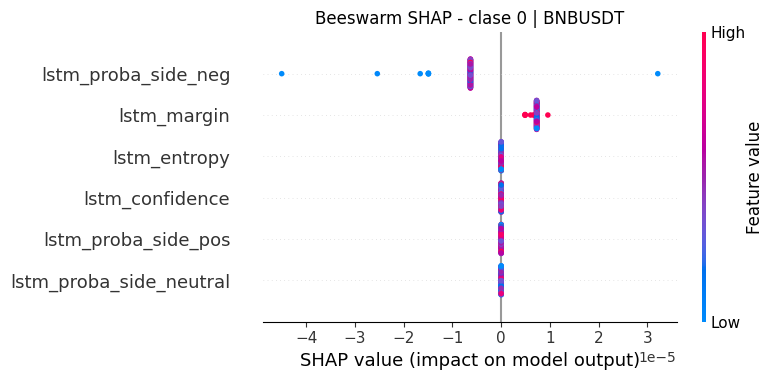

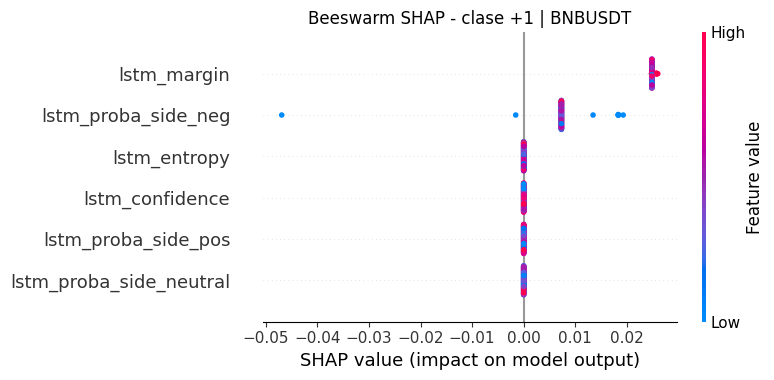

In [25]:

def _save_beeswarm(label_idx: int, label_name: str):
    import shap
    fig = plt.figure(figsize=(7, max(3.5, 0.32 * len(corrector_feature_names))))
    shap.summary_plot(
        shap_by_class[label_idx],
        explain_set,
        feature_names=corrector_feature_names,
        show=False,
    )
    plt.title(f"Beeswarm SHAP - clase {label_name} | {SYMBOL}")
    plt.tight_layout()
    out_path = SYMBOL_REPORT_DIR / (
        "shap_beeswarm_class_" + label_name.replace("+", "p").replace("-", "m") + ".png"
    )
    fig.savefig(out_path, dpi=140)
    plt.show()

for lbl, name in [(-1, "-1"), (0, "0"), (1, "+1")]:
    _save_beeswarm(lbl, name)


## 5. Persistencia de evidencias

Artefactos exportados bajo `reports/validation/explainability/bnbusdt/`:

- `shap_summary.json`
- `shap_stage1_feature_importance.png`, `shap_stage1_time_heatmap.png`
- `shap_feature_importance.png`
- `shap_beeswarm_class_m1.png`, `shap_beeswarm_class_0.png`, `shap_beeswarm_class_p1.png`


In [26]:

top_per_class = {}
for label in [-1, 0, 1]:
    col = f"clase_{label:+d}"
    top_per_class[str(label)] = (
        importance_df[[col]].sort_values(col, ascending=False).reset_index().rename(columns={"index": "feature", col: "mean_abs_shap"}).to_dict(orient="records")
    )

shap_summary = {
    "symbol": handle.symbol,
    "family": handle.family,
    "engine_family": handle.engine_family,
    "lane": handle.lane,
    "active_blocks_id": handle.active_blocks_id,
    "labeling_method": handle.labeling_method,
    "study_id": handle.study_id,
    "last_fold_dir": handle.last_fold_dir.relative_to(REPO_ROOT).as_posix(),
    "n_test_windows": int(corrector_input_test.shape[0]),
    "n_explained": int(explanation["n_explained"]),
    "n_background": int(explanation["background_size"]),
    "n_corrector_features": len(corrector_feature_names),
    "explainer": "KernelExplainer (predict_proba)",
    "stage1_feature_columns": list(handle.feature_channel_order),
    "stage2_feature_columns": list(corrector_feature_names),
    "corrector_base_feature_columns": list(residual_manifest.get("corrector_base_feature_columns") or []),
    "stage1_feature_importance": stage1_importance_df.to_dict(orient="index"),
    "stage1_top_features_per_class": {
        str(label): (
            stage1_importance_df[[f"clase_{label:+d}"]]
            .sort_values(f"clase_{label:+d}", ascending=False)
            .head(5)
            .reset_index()
            .rename(columns={"index": "feature", f"clase_{label:+d}": "mean_abs_shap"})
            .to_dict(orient="records")
        )
        for label in [-1, 0, 1]
    },
    "stage2_feature_importance": importance_df.to_dict(orient="index"),
    "stage2_top_features_per_class": top_per_class,
    "feature_importance": importance_df.to_dict(orient="index"),
    "top_features_per_class": top_per_class,
    "stage1_pred_class_counts": {str(k): int(v) for k, v in zip(*np.unique(np.array([-1,0,1])[np.argmax(stage1_proba_test, axis=1)], return_counts=True))},
    "stage2_pred_class_counts": {str(k): int(v) for k, v in zip(*np.unique(corrector_pred_test, return_counts=True))},
    "stage2_confidence_p50": float(np.median(corrector_conf_test)),
    "stage2_confidence_p90": float(np.quantile(corrector_conf_test, 0.9)),
}
out_path = SYMBOL_REPORT_DIR / "shap_summary.json"
out_path.write_text(json.dumps(shap_summary, indent=2, default=float), encoding="utf-8")
print("Reporte persistido en", out_path.relative_to(REPO_ROOT))


Reporte persistido en reports/validation/explainability/bnbusdt/shap_summary.json


## 6. Lectura cualitativa BNBUSDT (stage1 + stage2)

El SHAP de dos niveles permite ahora separar la responsabilidad del backbone LSTM (stage1) del corrector XGBoost (stage2):

### Stage1 LSTM: ¿qué canales técnicos explican las 180 ventanas alcistas?

- **Predicciones del LSTM**: 180/180 = +1. La red está saturada hacia la clase alcista en este *fold*.
- **Magnitudes |SHAP|**: muy bajas (orden 1e-3), coherente con un decisor saturado: pequeñas variaciones de los canales no mueven la probabilidad porque ya está cerca de 1.
- **Top canales por clase de salida**:
  - Clase `+1` (la dominante): `macd_line` (~0.0024), `pvt`, `stoch_k_14`, `macd_signal`, `atr_14` -> **momentum y volumen confirmando tendencia**.
  - Clase `-1` (residual, no se predice): `macd_signal`, `roc_12`, `vol_sma_ratio_20`, `macd_hist`, `bbands_pctb_20` -> los *contraindicadores* que evitarían el largo si llegaran a invertirse.
  - Clase `0`: `vol_sma_ratio_20`, `macd_line`, `slope_sma_20`, `atr_14`, `roc_12` -> filtro de régimen lateral que el LSTM rechaza activamente.
- **Lectura**: el LSTM concentra su decisión en un *cluster* MACD + volumen + slope. La saturación implica que estos canales operan por encima de un umbral interno; los SHAP residuales solo redistribuyen probabilidad de cola, no cambian la clase.

### Stage2 corrector: passthrough estructural

- **Predicciones del corrector**: 180/180 = +1, confianza fija p50 = p90 = 0.680.
- **Top features SHAP**: `lstm_margin` (0.025 por clase) concentra casi toda la atribución; `lstm_proba_side_neg` (~0.008) es residual; las demás señales LSTM colapsan a 0.
- **Lectura**: el corrector es un **passthrough estructural** del LSTM en este *fold*. Como `corrector_base_feature_columns = []` (bloque `core_only`), no puede introducir información nueva; simplemente confirma la dirección saturada del stage1.

### Implicación combinada

Sin el stage1 SHAP, la conclusión sería que el corrector no aporta valor. Con ambos niveles documentamos algo más fuerte: **el LSTM ya ha consumido toda la información disponible en los canales técnicos `core_only` y emite una decisión saturada que el corrector solo puede ratificar**. La promoción de BNB se sostiene por el LSTM, no por el corrector. Si en futuras revisiones se reactivara la búsqueda de bloque alternativo (`sentiment`, `derivatives_futures`, etc.), aquí está el argumento empírico para hacerlo: el `core_only` está agotado.

